In [ ]:
import os.path as osp
import sys
sys.path.append('../../')
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

import numpy as np
from sklearn import metrics, calibration

import matplotlib
import matplotlib.pyplot as plt

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import qdre

from qdre.plotting import get_scores, get_r_hats
from evaluation_helpers import plot_closure

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


In [2]:
SAVE_DIR = "./models"
DATA_DIR = "./data"

source_file = osp.join(DATA_DIR, "SMEFT_SM_combined_tuple")
target_file = osp.join(DATA_DIR, "SMEFT_EFT_combined_tuple")

submodel_names = np.array(["Pos", "Neg", "Pos", "Neg"])
combos = [np.array((0,2)), #++
          np.array((0,3))] #+-

NUM_MODELS = 2

In [3]:
batch_sizes = [int(2**8), int(2**8)]

model_paths = [osp.join(SAVE_DIR, "classifier_subdensity_{}_batch{}.zip".format(''.join(submodel_names[combos[i]]), batch_sizes[i])) for i in range(NUM_MODELS)]

training_settings = [qdre.train.load_training_settings(model_path) for model_path in model_paths]

models = [qdre.models.load_model(model_path, device=DEVICE).to(DEVICE) for model_path in model_paths]

training_settings[0].keys()

dict_keys(['batch_size', 'learning_rate', 'n_epochs', 'n_test', 'n_train', 'n_val', 'optimizer', 'random_seed', 'source_file', 'target_file', 'training_losses', 'validation_losses'])

In [4]:
source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

train_datasizes = []
val_datasizes = []
test_datasizes = []
for f in files:
    train_datasizes.append(np.load(f + "_train.npy").shape[0])
    val_datasizes.append(np.load(f + "_val.npy").shape[0])
    test_datasizes.append(np.load(f + "_test.npy").shape[0])

train_datasizes = np.array(train_datasizes)
val_datasizes = np.array(val_datasizes)
test_datasizes = np.array(test_datasizes)
train_datasizes

array([776369,      0, 641157, 135212])

In [5]:
test_generator_datas = []
for i in range(NUM_MODELS):
    test_base_dataset = qdre.preprocessing.Dataset(files[combos[i][0]] + "_test.npy", 0)

    test_target_dataset = qdre.preprocessing.Dataset(files[combos[i][1]] + "_test.npy", 1)
    
    test_base_dataset.process(normalize_weights=True)
    test_target_dataset.process(normalize_weights=True)
    
    test_generator_datas.append(qdre.preprocessing.CombinedDataset(test_base_dataset, test_target_dataset))

In [6]:
test_base_dataset.n_events, test_target_dataset.n_events

(238883, 41780)

In [7]:
X_scalers, weight_norms = list(zip(*[qdre.preprocessing.load_scaling(model_path) for model_path in model_paths]))

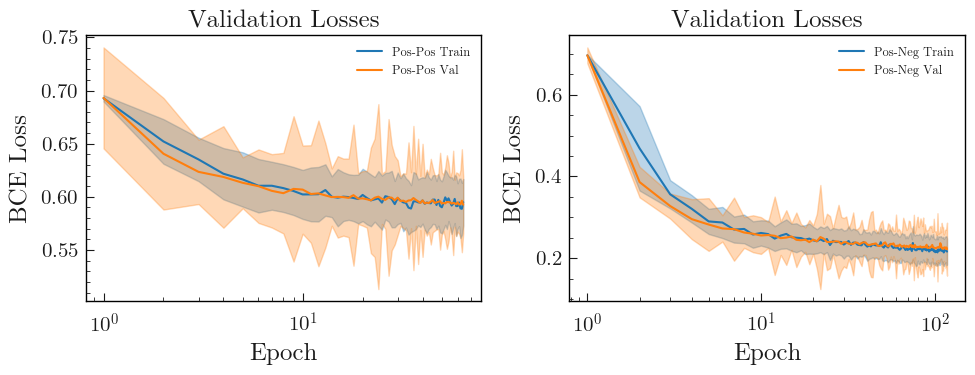

In [8]:
fig,ax = plt.subplots(1,2)
fig.set_size_inches(10,4)

training_losses = [ts["training_losses"] for ts in training_settings]
validation_losses = [ts["validation_losses"] for ts in training_settings]

starting_epoch = 0

training_loss_per_epoch = [np.array(tl[starting_epoch:]).mean(axis=1) for tl in training_losses]
training_std_per_epoch = [np.array(tl[starting_epoch:]).std(axis=1) for tl in training_losses]

validation_loss_per_epoch = [np.array(vl[starting_epoch:]).mean(axis=1) for i, vl in enumerate(validation_losses)]
validation_std_per_epoch = [np.array(vl[starting_epoch:]).std(axis=1) for i, vl in enumerate(validation_losses)]

training_lower_bar = [training_loss_per_epoch[i] - training_std_per_epoch[i] for i in range(NUM_MODELS)]
training_upper_bar = [training_loss_per_epoch[i] + training_std_per_epoch[i] for i in range(NUM_MODELS)]

validation_lower_bar = [validation_loss_per_epoch[i] - validation_std_per_epoch[i] for i in range(NUM_MODELS)]
validation_upper_bar = [validation_loss_per_epoch[i] + validation_std_per_epoch[i] for i in range(NUM_MODELS)]


t = [np.arange(len(validation_loss_per_epoch[i])) + 1 for i in range(NUM_MODELS)]
names = ["Pos-Pos", "Pos-Neg"]

for i in range(NUM_MODELS):
    ax[i].plot(t[i], training_loss_per_epoch[i], label=names[i]+" Train", color="tab:blue")
    ax[i].fill_between(t[i], training_lower_bar[i], training_upper_bar[i], color='tab:blue', alpha=0.30)
    ax[i].plot(t[i], validation_loss_per_epoch[i], label=names[i]+" Val", color="tab:orange")
    ax[i].fill_between(t[i], validation_lower_bar[i], validation_upper_bar[i], color='tab:orange', alpha=0.30)

    ax[i].legend(prop={'size': 9})
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("BCE Loss")
    ax[i].set_title("Validation Losses")
    ax[i].set_xscale('log')

fig.tight_layout()

## Get the scores (model output) on the test data

In [9]:
batch_size = 1024
test_loaders = [DataLoader(test_generator_data, batch_size=batch_size, shuffle=False) for test_generator_data in test_generator_datas]

In [10]:
test_scores, test_targets, test_weights = list(zip(*[get_scores(
    models[i],
    test_loaders[i],
    X_scalers[i],
    leave=True,
    device=DEVICE
) for i in range(NUM_MODELS)]))

100%|██████████| 275/275 [00:01<00:00, 151.79it/s]


In [11]:
prob_true, prob_pred = list(zip(*[calibration.calibration_curve(
    test_targets[i],
    test_scores[i],
    n_bins=20
) for i in range(NUM_MODELS)]))

ONLY VALID IF THE TESTING DATASETS ARE EQUAL IN SIZE


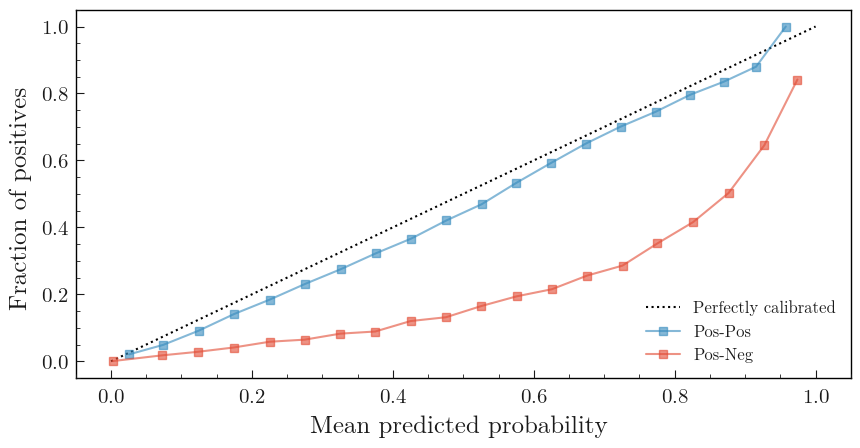

In [12]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax_calibration_curve = fig.add_subplot(gs[:2, :2])

names = ["Pos-Pos", "Pos-Neg"]
disp = [calibration.CalibrationDisplay(prob_true[i], prob_pred[i], test_scores[i], estimator_name=names[i]) for i in range(NUM_MODELS)]

[d.plot(ax=ax_calibration_curve, alpha=0.6) for d in disp]
#disp[0].plot()
print("ONLY VALID IF THE TESTING DATASETS ARE EQUAL IN SIZE")

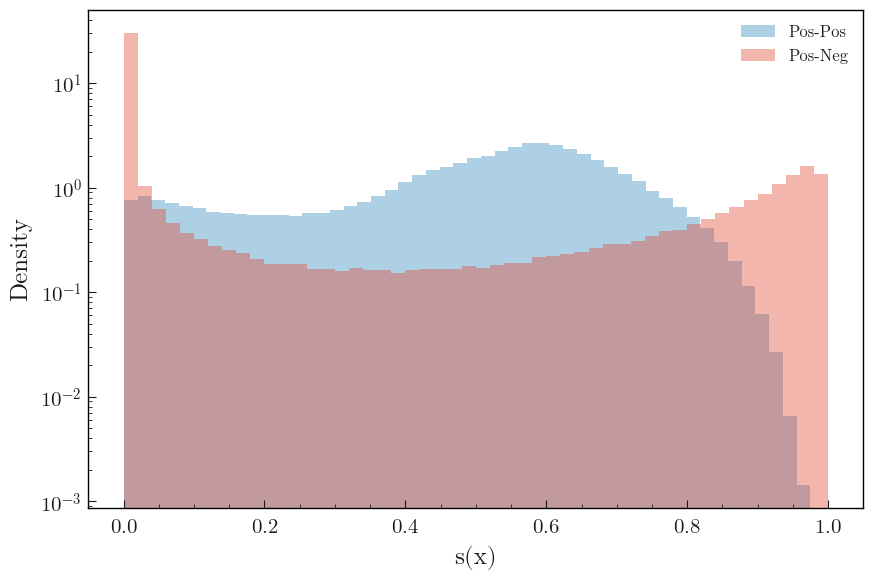

In [13]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(3, 2)
ax = fig.add_subplot(gs[:2, :2])

names = ["Pos-Pos", "Pos-Neg"]
hist = [ax.hist(test_scores[i], weights=test_weights[i], bins=50, alpha=0.4, density=True, label=names[i]) for i in range(NUM_MODELS)]

ax.legend()
ax.set_xlabel("s(x)")
ax.set_ylabel("Density")
ax.set_yscale('log')
#[d.plot(ax=ax_calibration_curve, alpha=0.6) for d in disp]
#disp[0].plot()

## Evaluate the ROC curve for the model

In [14]:
auc_scores = [metrics.roc_auc_score(test_targets[i], test_scores[i], sample_weight=test_weights[i]) for i in range(NUM_MODELS)]

#print("Area under the ROC curve for the subdensities: [{:.4}, {:.4}]".format(*auc_scores))

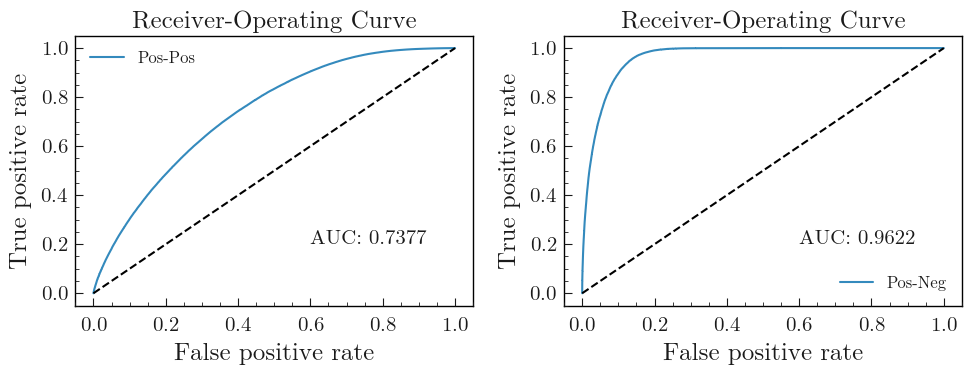

In [15]:
fpr, tpr, thresholds = list(zip(*[metrics.roc_curve(test_targets[i], test_scores[i], pos_label=1, sample_weight=test_weights[i]) for i in range(NUM_MODELS)]))

fig,ax = plt.subplots(1,2)
fig.set_size_inches(10,4)

names = ["Pos-Pos", "Pos-Neg"]

for i in range(NUM_MODELS):
    ax[i].plot(fpr[i], tpr[i], label=names[i])
    ax[i].plot(np.linspace(0,1,20), np.linspace(0,1,20), '--', c="black")
    ax[i].set_xlabel("False positive rate")
    ax[i].set_ylabel("True positive rate")
    ax[i].set_title("Receiver-Operating Curve")
    ax[i].legend()
    ax[i].text(0.6, 0.2, "AUC: {:.4}".format(auc_scores[i]));

fig.tight_layout()

## Get the CARL weights

In [16]:
test_nominal_loaders = []
test_target_loaders = []
for i in range(NUM_MODELS):
# We flip the labels here so we learn the ratio of Y=0/Y=1 when we use the regular s/(1-s) trick, which is what we want for the subdensities
    test_base_dataset = qdre.preprocessing.Dataset(files[combos[i][0]] +"_test.npy", 0)#,
                                                    #stop_event=training_settings[i]["n_test"])
    
    test_target_dataset = qdre.preprocessing.Dataset(files[combos[i][1]] +"_test.npy", 1)#,
                                                    #stop_event=training_settings[i]["n_test"])

    weight_norm = 1
    if combos[i][0] == 1:
        weight_norm = -1
    test_base_dataset.process(normalize_weights=True, weight_norm=weight_norm)
    
    weight_norm = 1
    if combos[i][1] == 3:
        weight_norm = -1
    test_target_dataset.process(normalize_weights=True, weight_norm=weight_norm)

    test_nominal_loaders.append(DataLoader(qdre.preprocessing.CombinedDataset(test_base_dataset), batch_size=batch_size, shuffle=False))
    test_target_loaders.append(DataLoader(qdre.preprocessing.CombinedDataset(test_target_dataset), batch_size=batch_size, shuffle=False))

In [17]:
r_hats = [get_r_hats(
            models[i],
            test_nominal_loaders[i],
            X_scalers[i],
            leave=True,
            device=DEVICE
) for i in range(NUM_MODELS)]

100%|██████████| 234/234 [00:01<00:00, 177.38it/s]


## Get the data for plotting

In [18]:
keys = ['Jet_Eta',
        'Jet_Mass',
        'Jet_Phi',
        'Jet_Pt',
        'Muon_Eta0',
        'Muon_Eta1',
        'Muon_Eta2',
        'Muon_Eta3',
        'Muon_Phi0',
        'Muon_Phi1',
        'Muon_Phi2',
        'Muon_Phi3',
        'Muon_Pt0',
        'Muon_Pt1',
        'Muon_Pt2'
        'Muon_Pt3',]

model_names = ["Pos-Pos", "Pos-Neg"]
target_distribution_names = ["SM+EFT Positives", "SM+EFT Negatives"]

## Plot the reweighted distributions

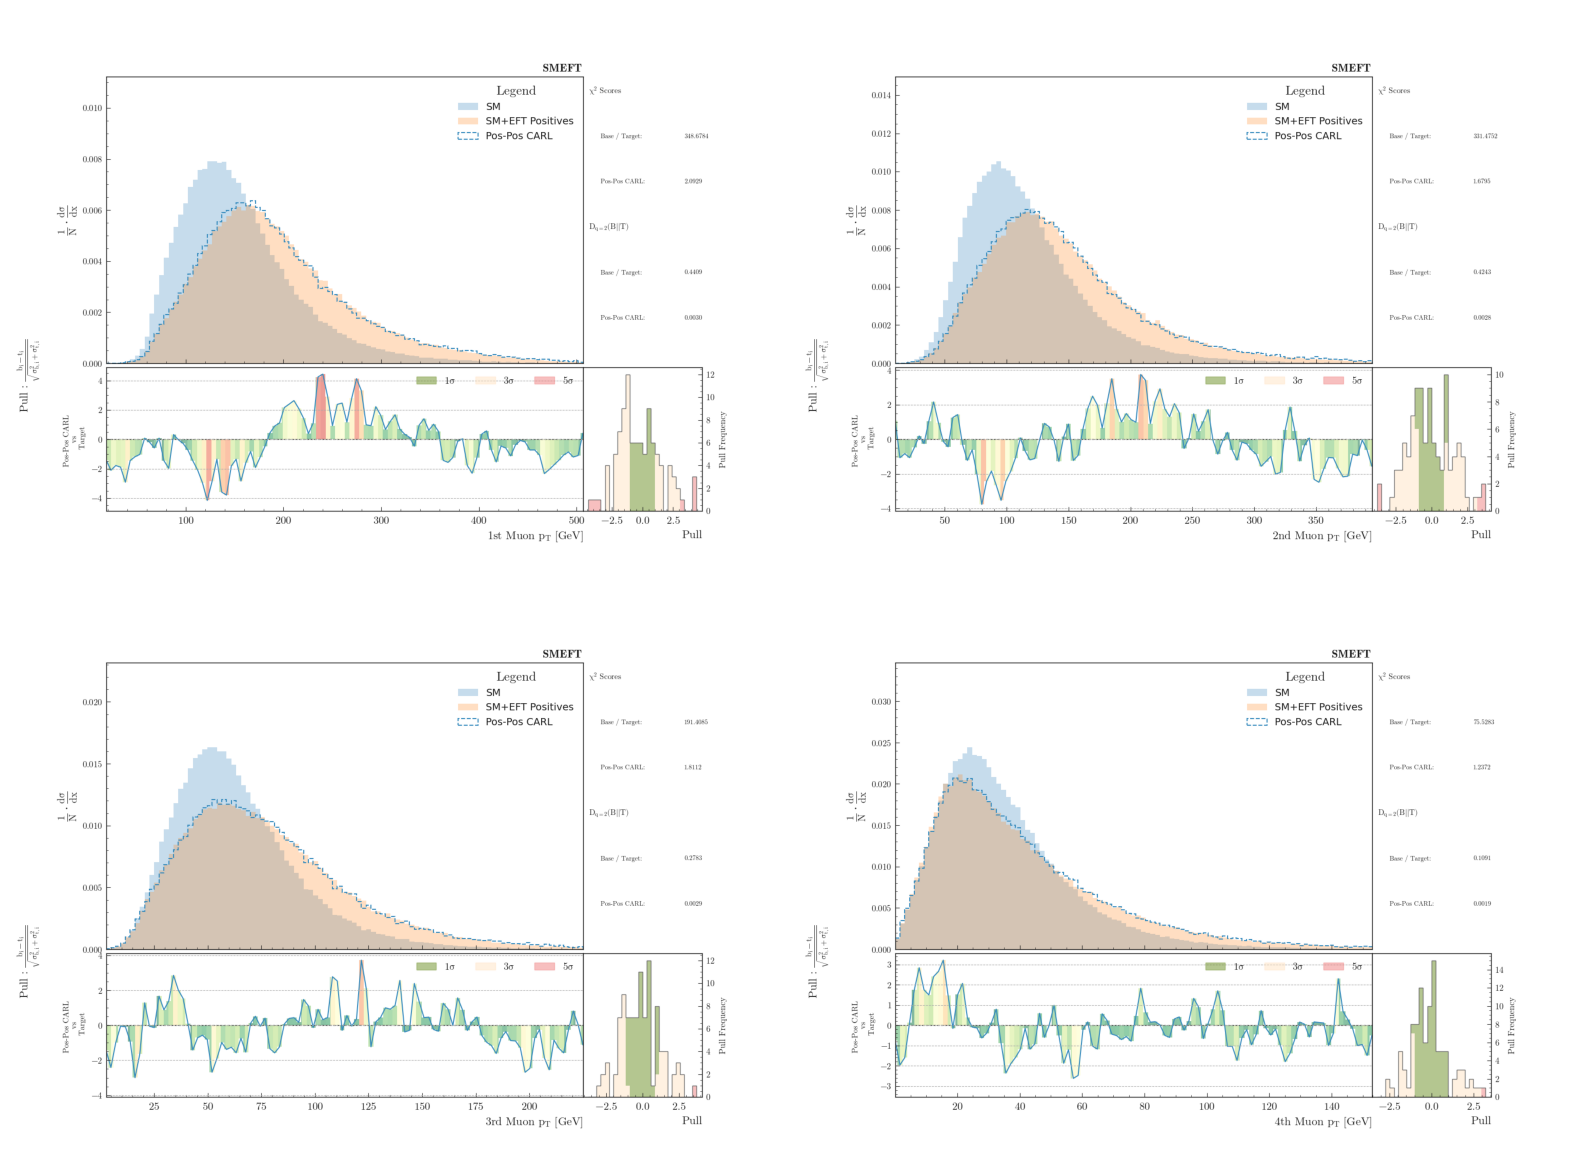

/home/mdrnevich/test/QuasiDRE/SMEFT/../qdre/plotting.py:450: RuntimeWarning: divide by zero encountered in divide
  x1_ratio = x0_hist/x1_hist
/home/mdrnevich/test/QuasiDRE/SMEFT/../qdre/plotting.py:454: RuntimeWarning: divide by zero encountered in divide
  carl_ratio = [carl_hist[0]/x1_hist for carl_hist in carl_hists]
/home/mdrnevich/test/QuasiDRE/SMEFT/../qdre/plotting.py:454: RuntimeWarning: invalid value encountered in divide
  carl_ratio = [carl_hist[0]/x1_hist for carl_hist in carl_hists]
/home/mdrnevich/test/QuasiDRE/SMEFT/../qdre/plotting.py:496: RuntimeWarning: invalid value encountered in scalar divide
  binsqrsum_x1 = binsqrsum_x1/w1[mask1].sum()


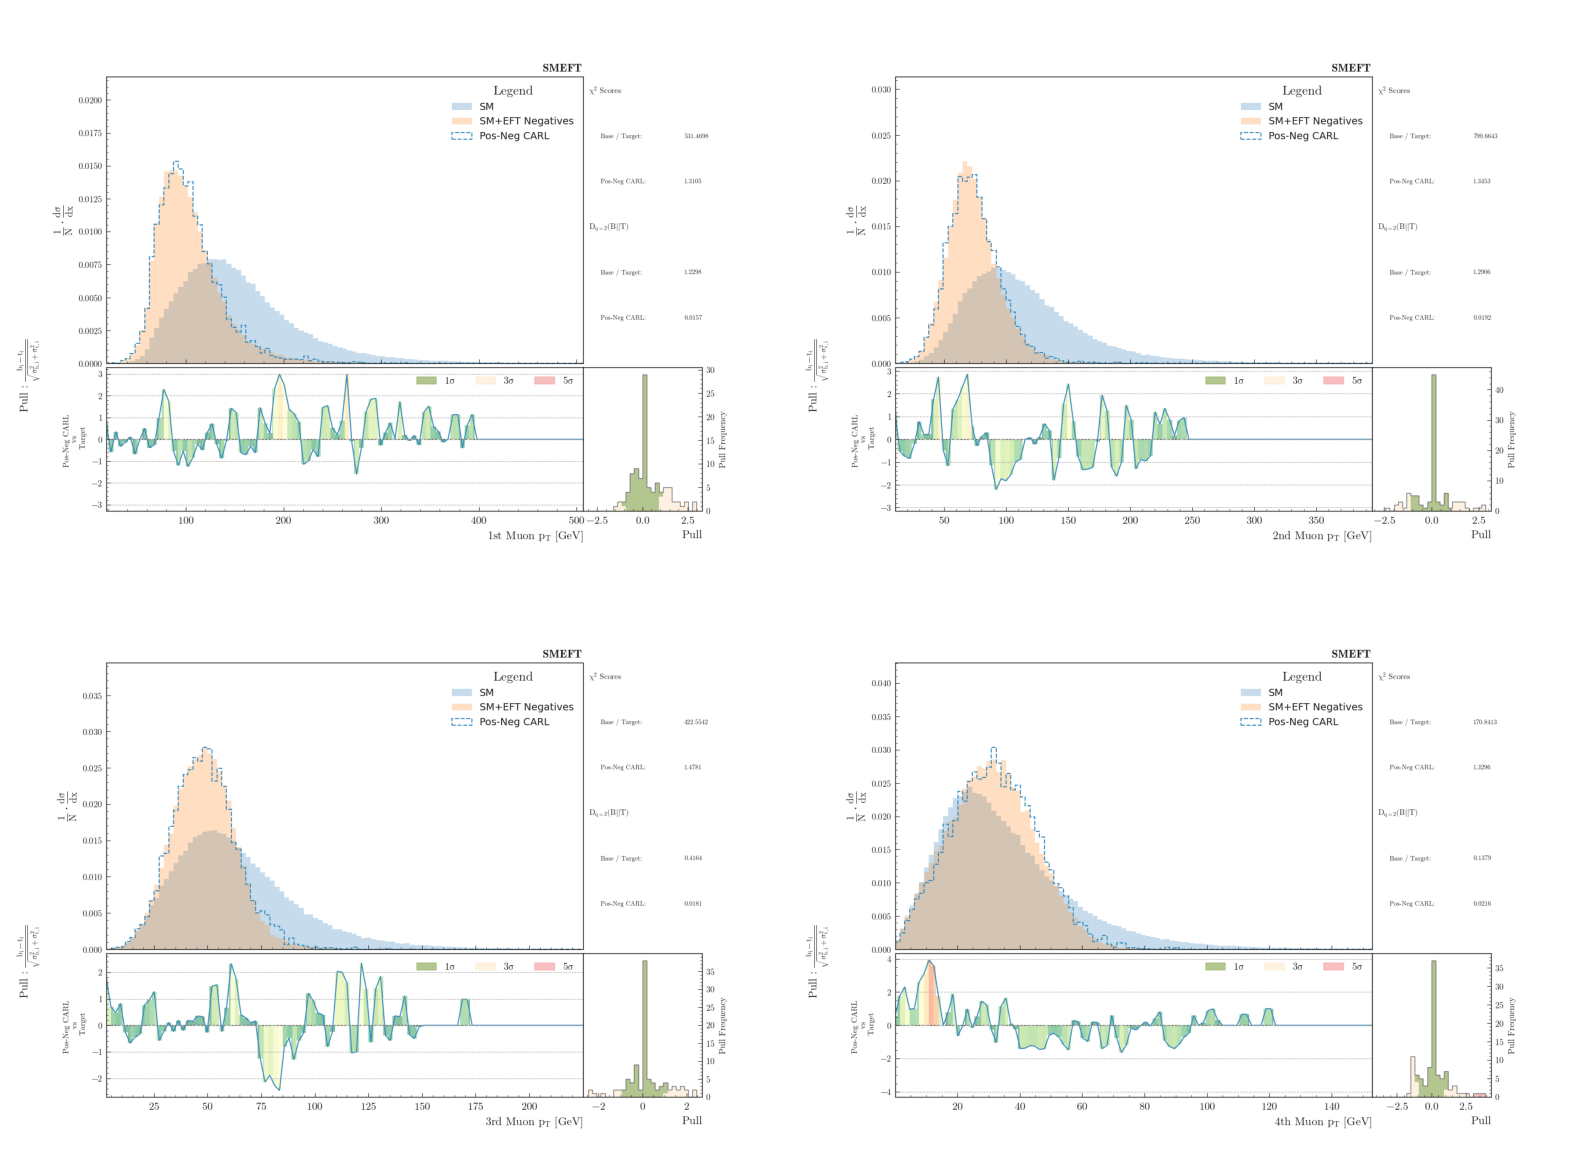

In [19]:
for idx in range(NUM_MODELS):
    plot_closure(r_hats[idx], test_nominal_loaders[idx], test_target_loaders[idx], model_names[idx], target_distribution_names[idx], keys, feature_group='muon_pt')

/home/mdrnevich/test/QuasiDRE/SMEFT/../qdre/plotting.py:450: RuntimeWarning: invalid value encountered in divide
  x1_ratio = x0_hist/x1_hist
/home/mdrnevich/test/QuasiDRE/SMEFT/../qdre/plotting.py:492: RuntimeWarning: invalid value encountered in scalar divide
  binsqrsum_x0 = binsqrsum_x0/w0[mask0].sum()


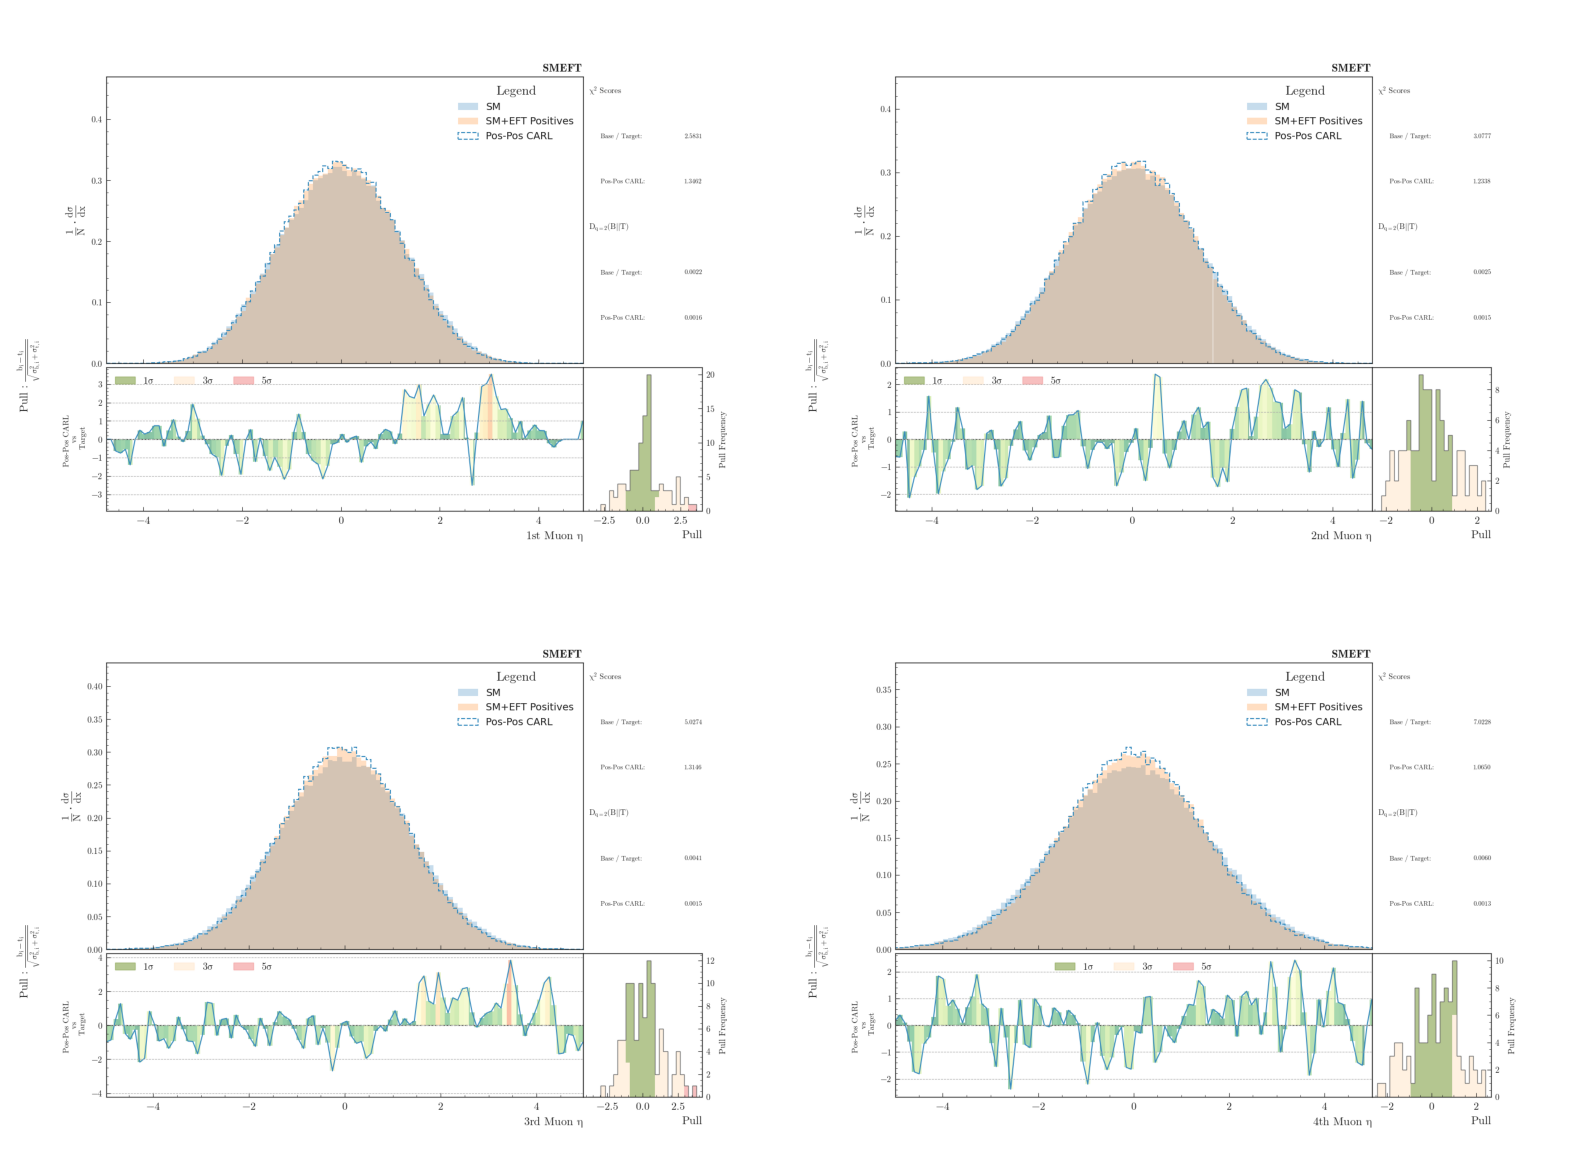

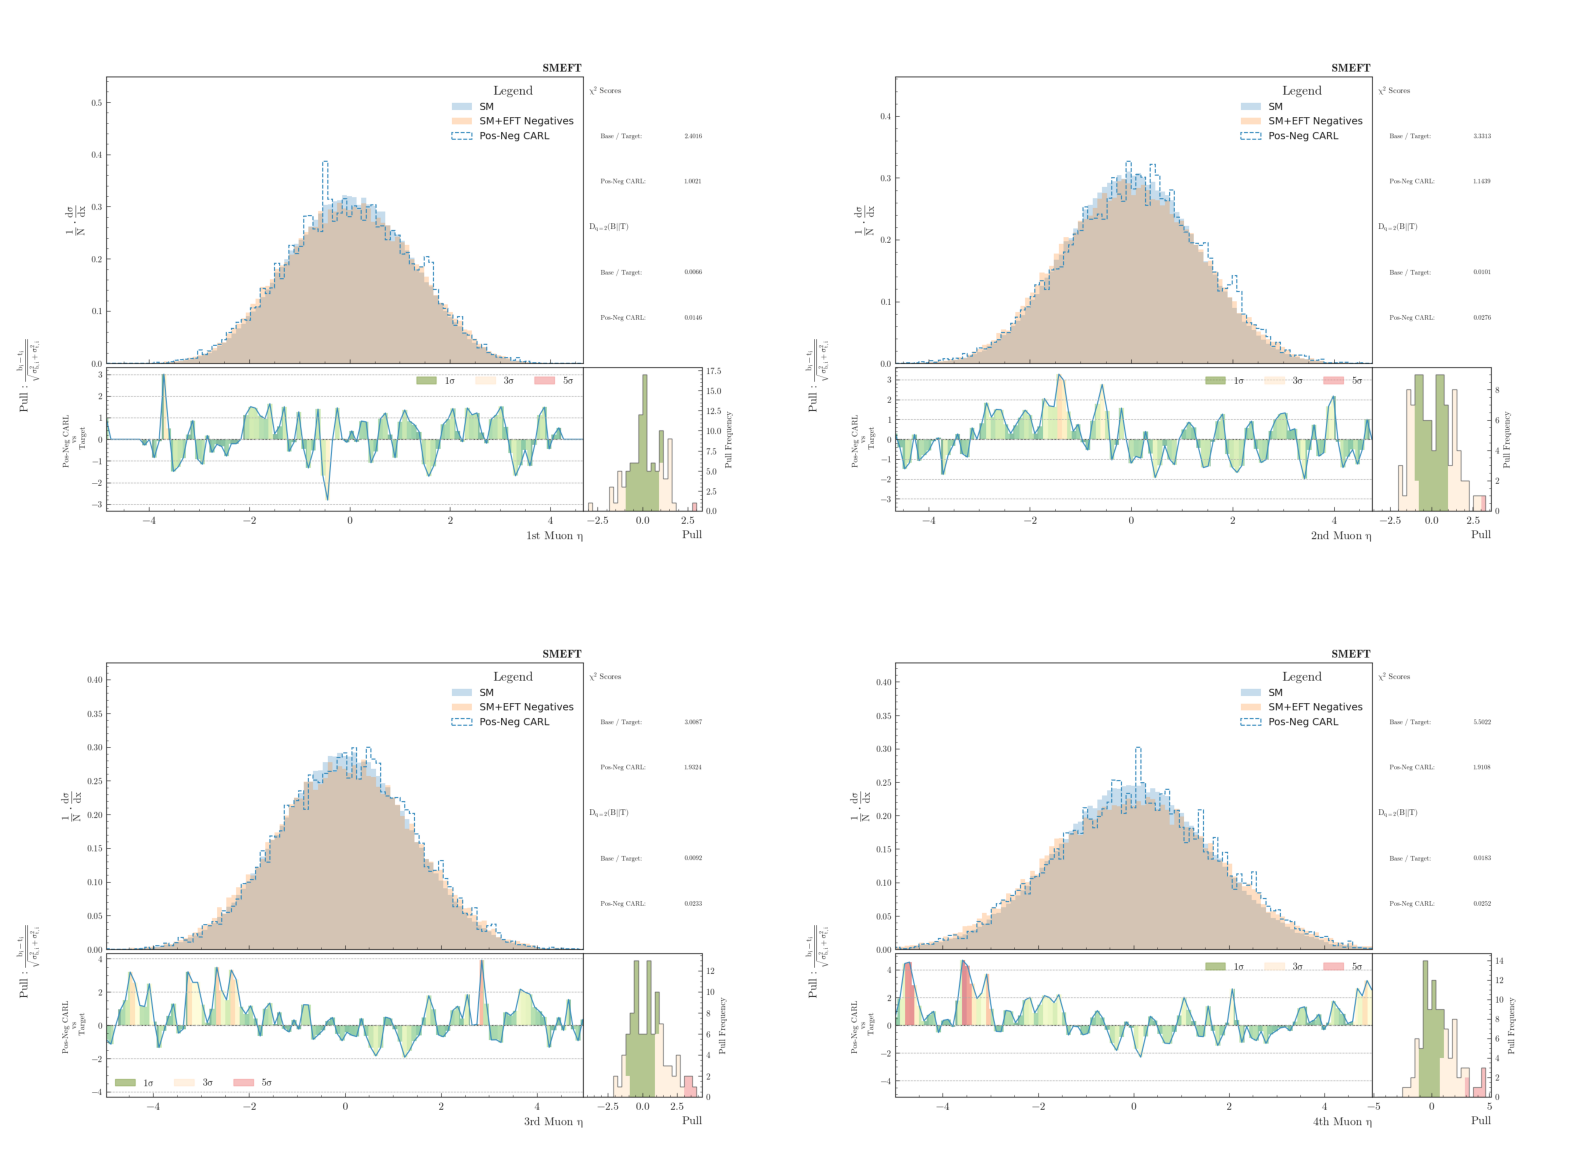

In [20]:
for idx in range(NUM_MODELS):
    plot_closure(r_hats[idx], test_nominal_loaders[idx], test_target_loaders[idx], model_names[idx], target_distribution_names[idx], keys, feature_group='muon_eta')

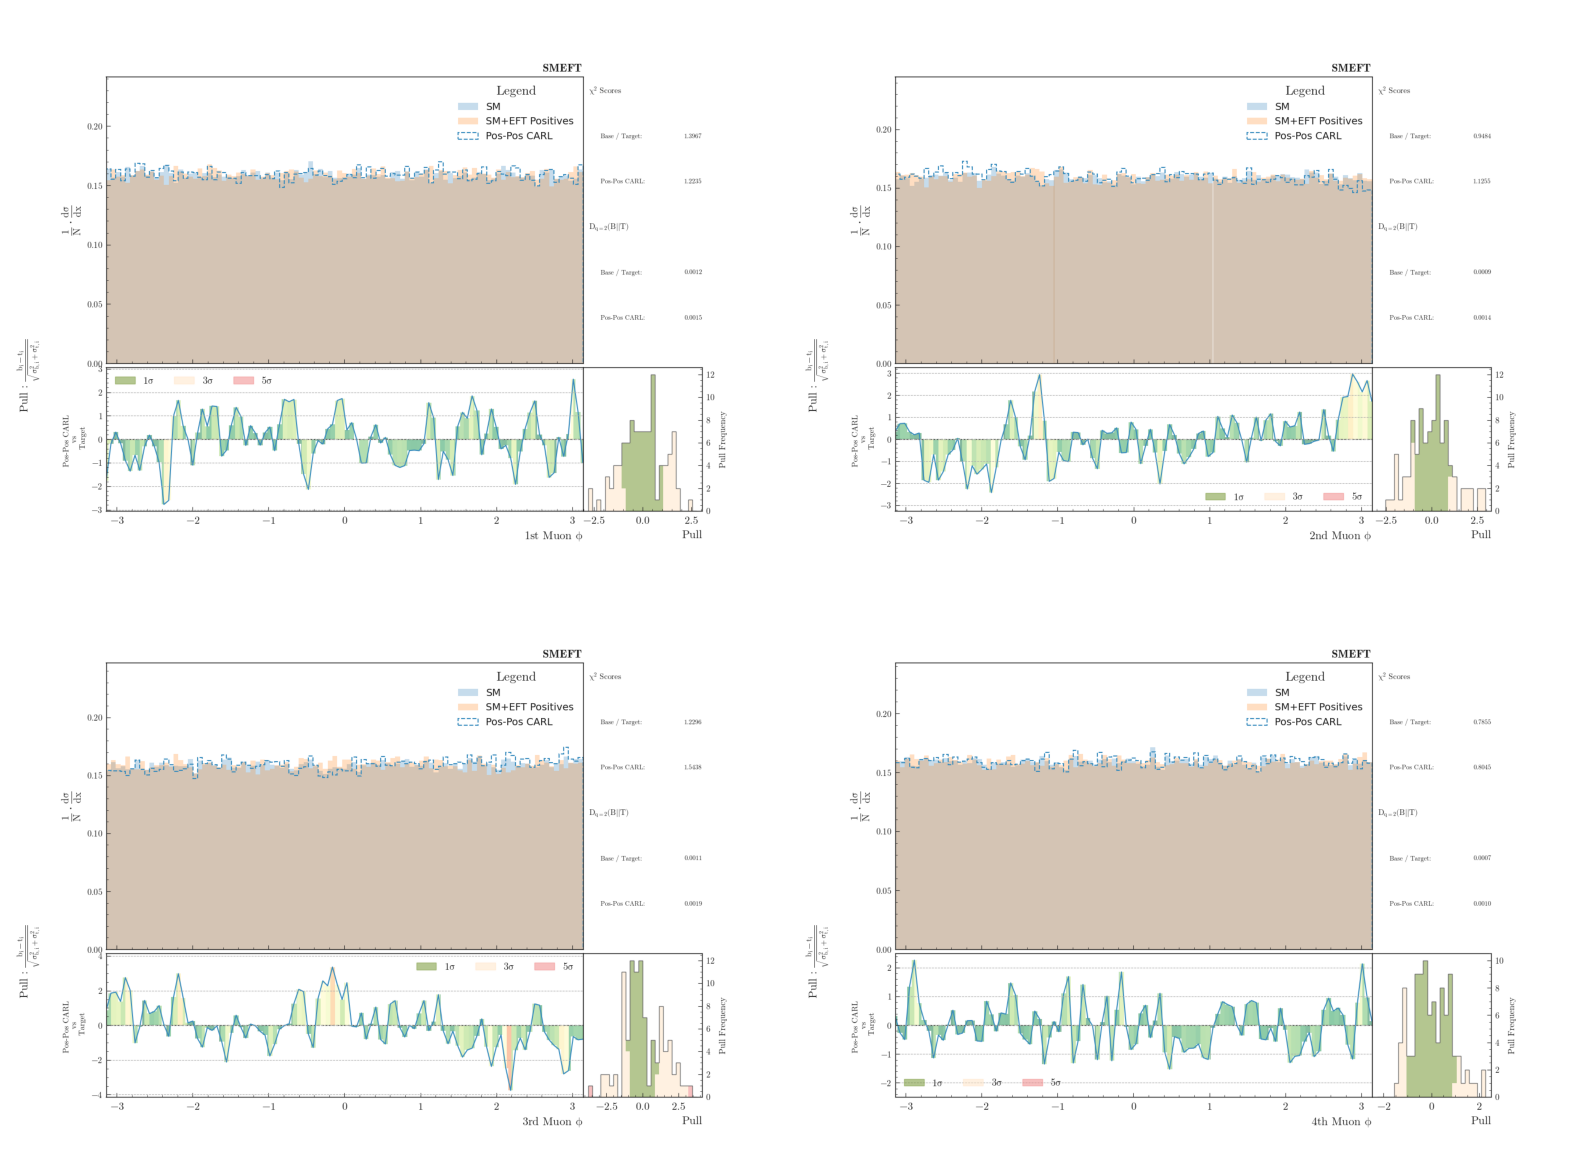

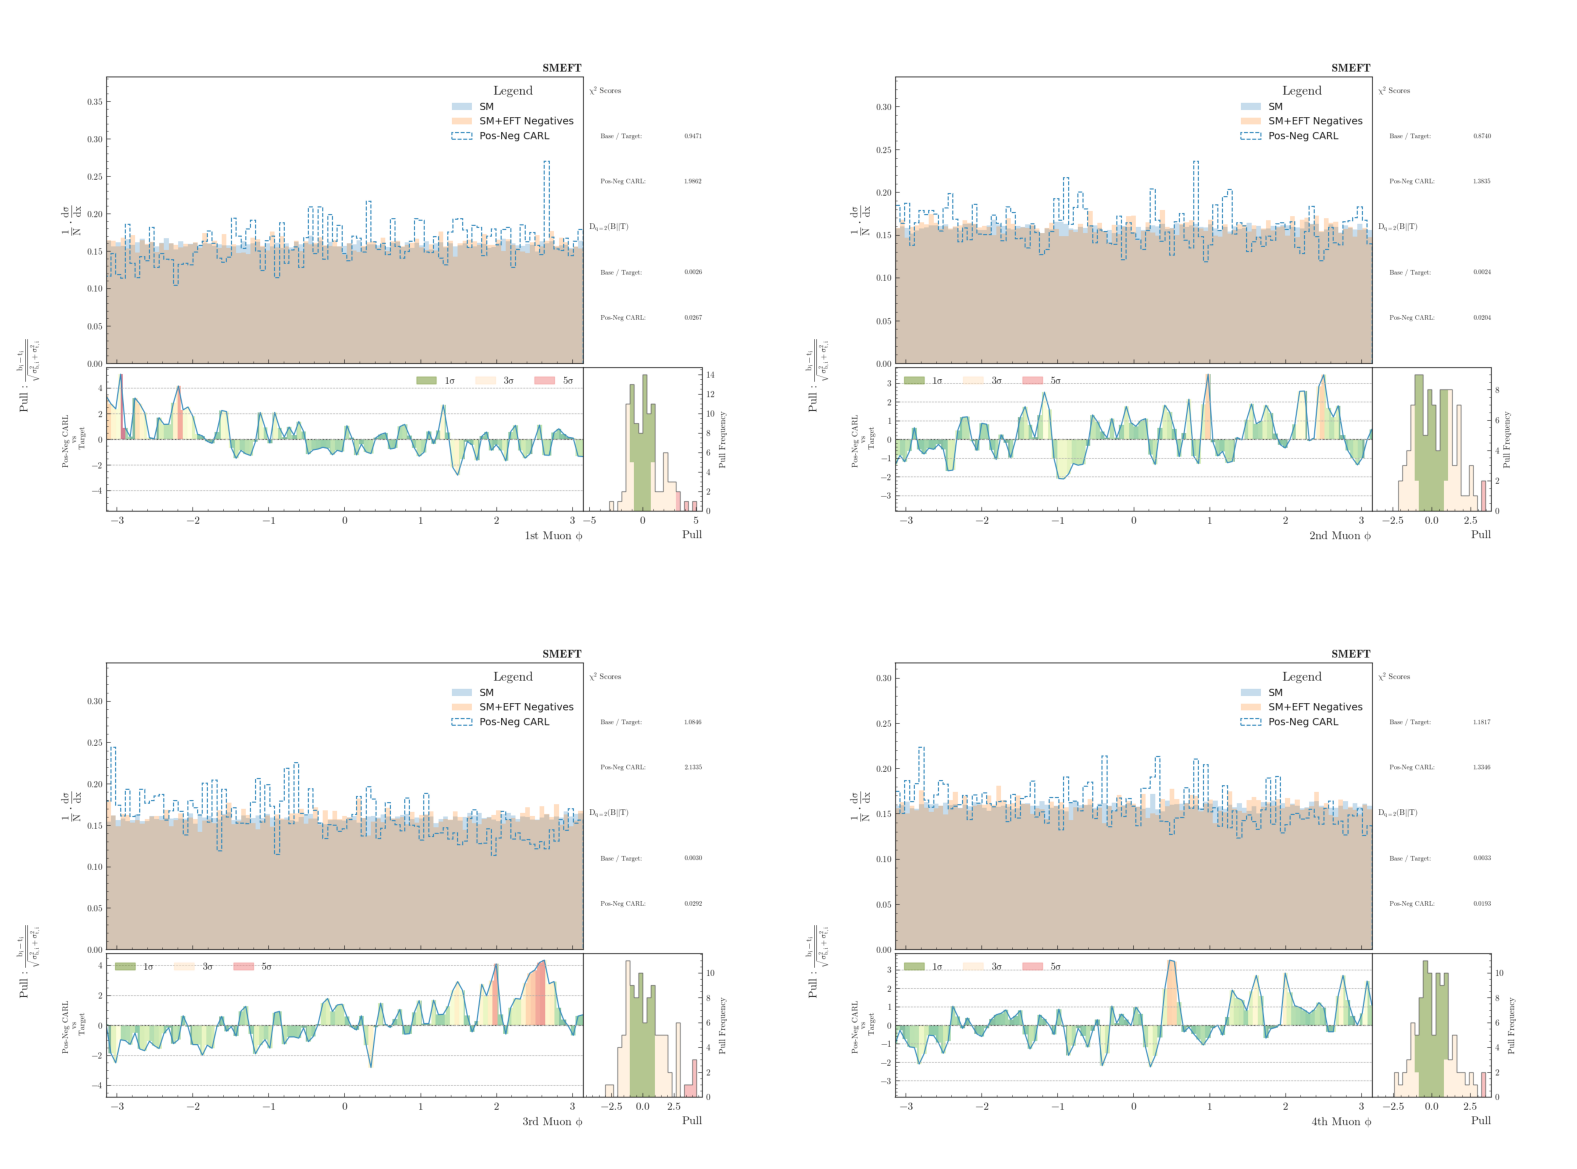

In [21]:
for idx in range(NUM_MODELS):
    plot_closure(r_hats[idx], test_nominal_loaders[idx], test_target_loaders[idx], model_names[idx], target_distribution_names[idx], keys, feature_group='muon_phi')

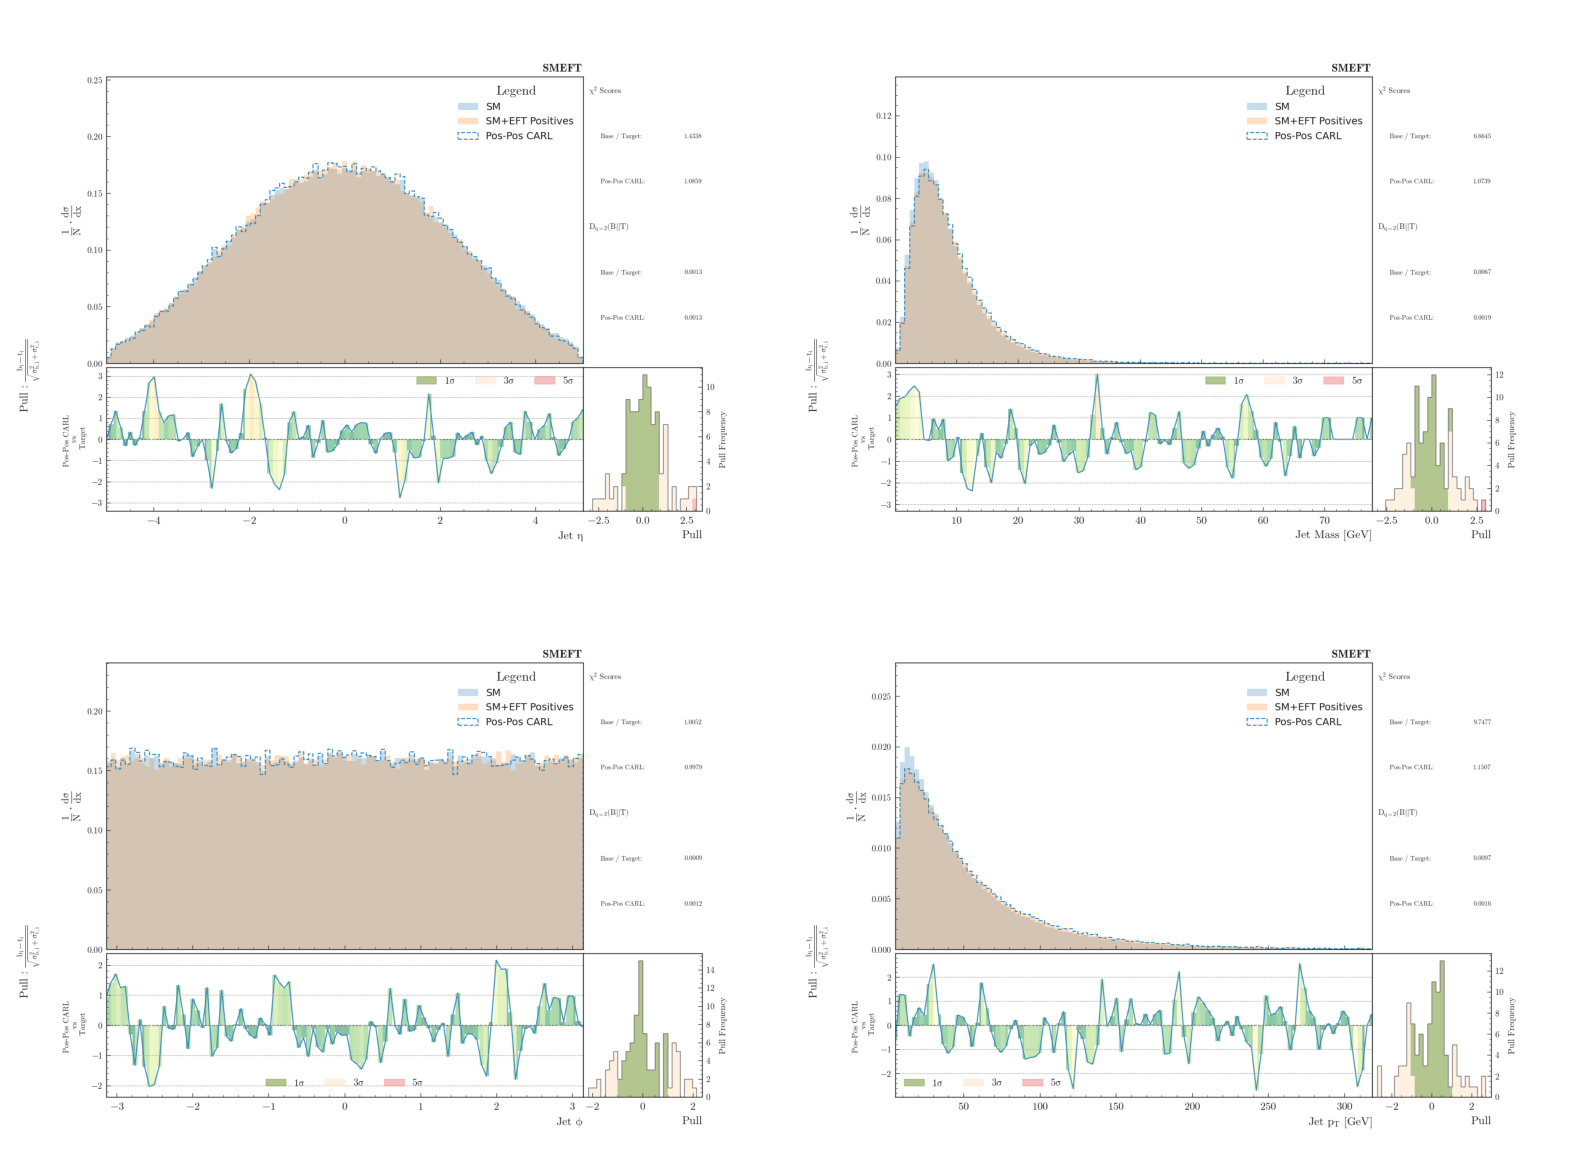

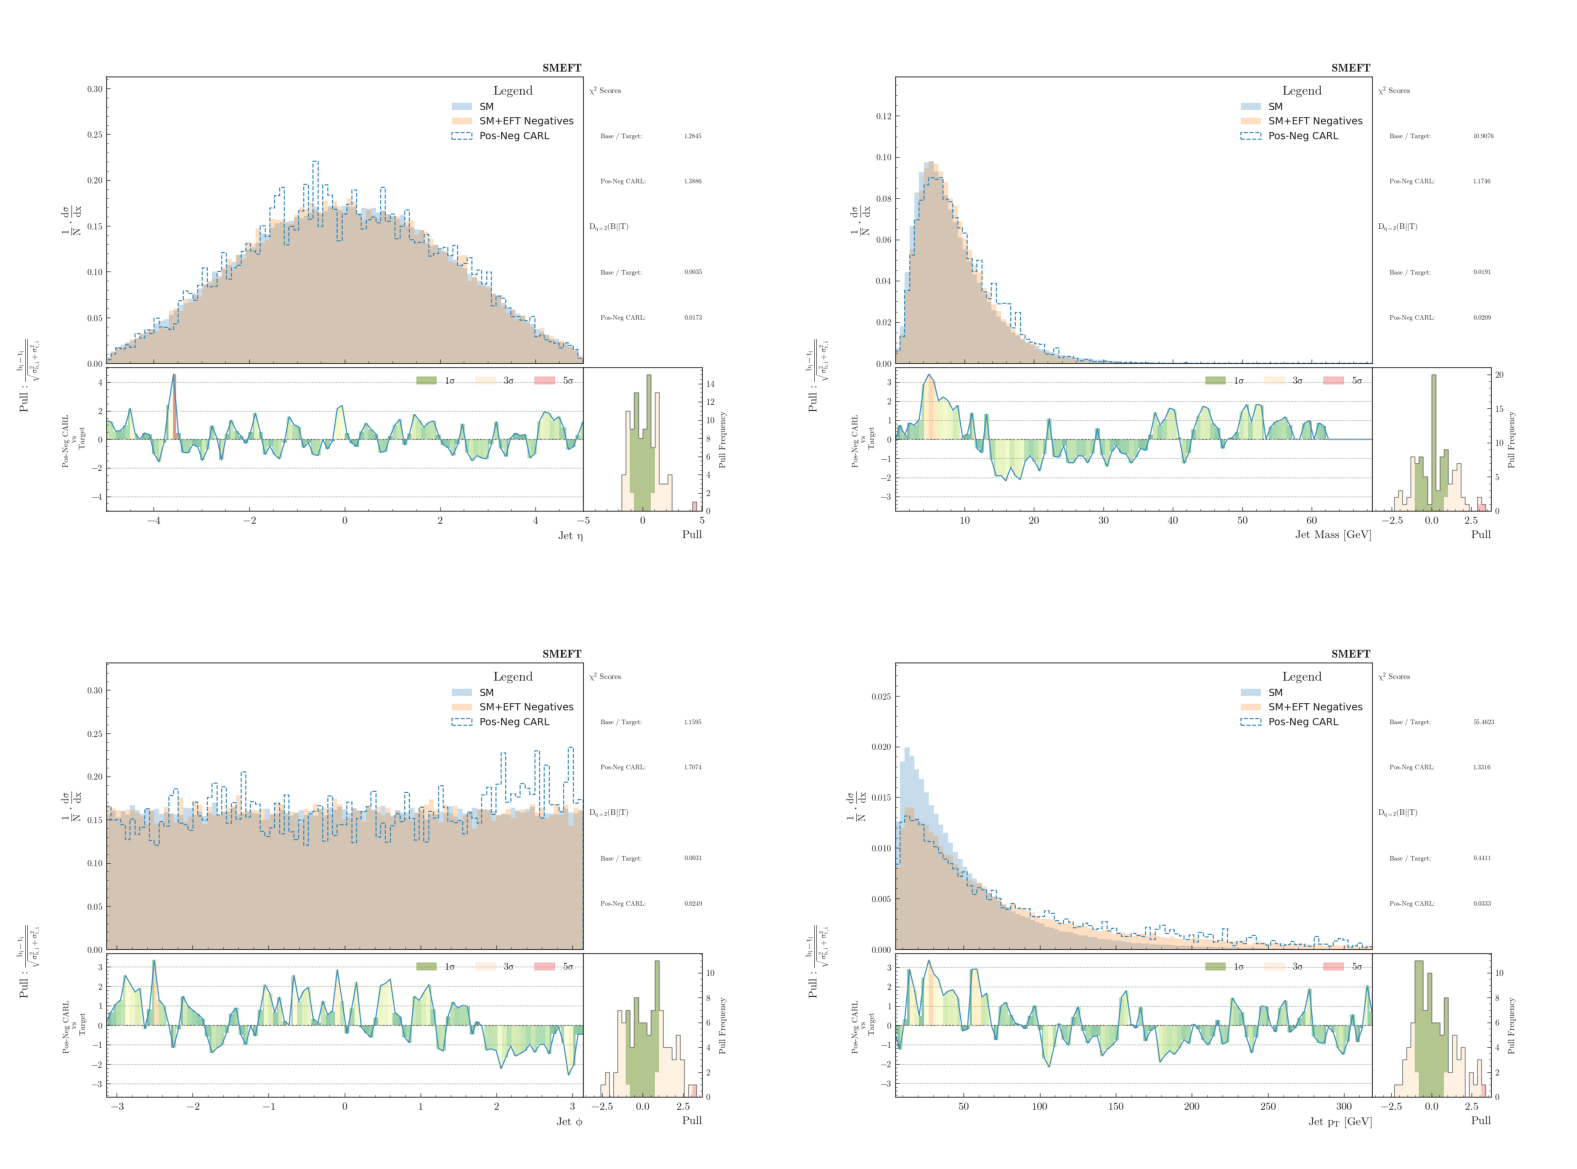

In [22]:
for idx in range(NUM_MODELS):
    plot_closure(r_hats[idx], test_nominal_loaders[idx], test_target_loaders[idx], model_names[idx], target_distribution_names[idx], keys, feature_group='jet')

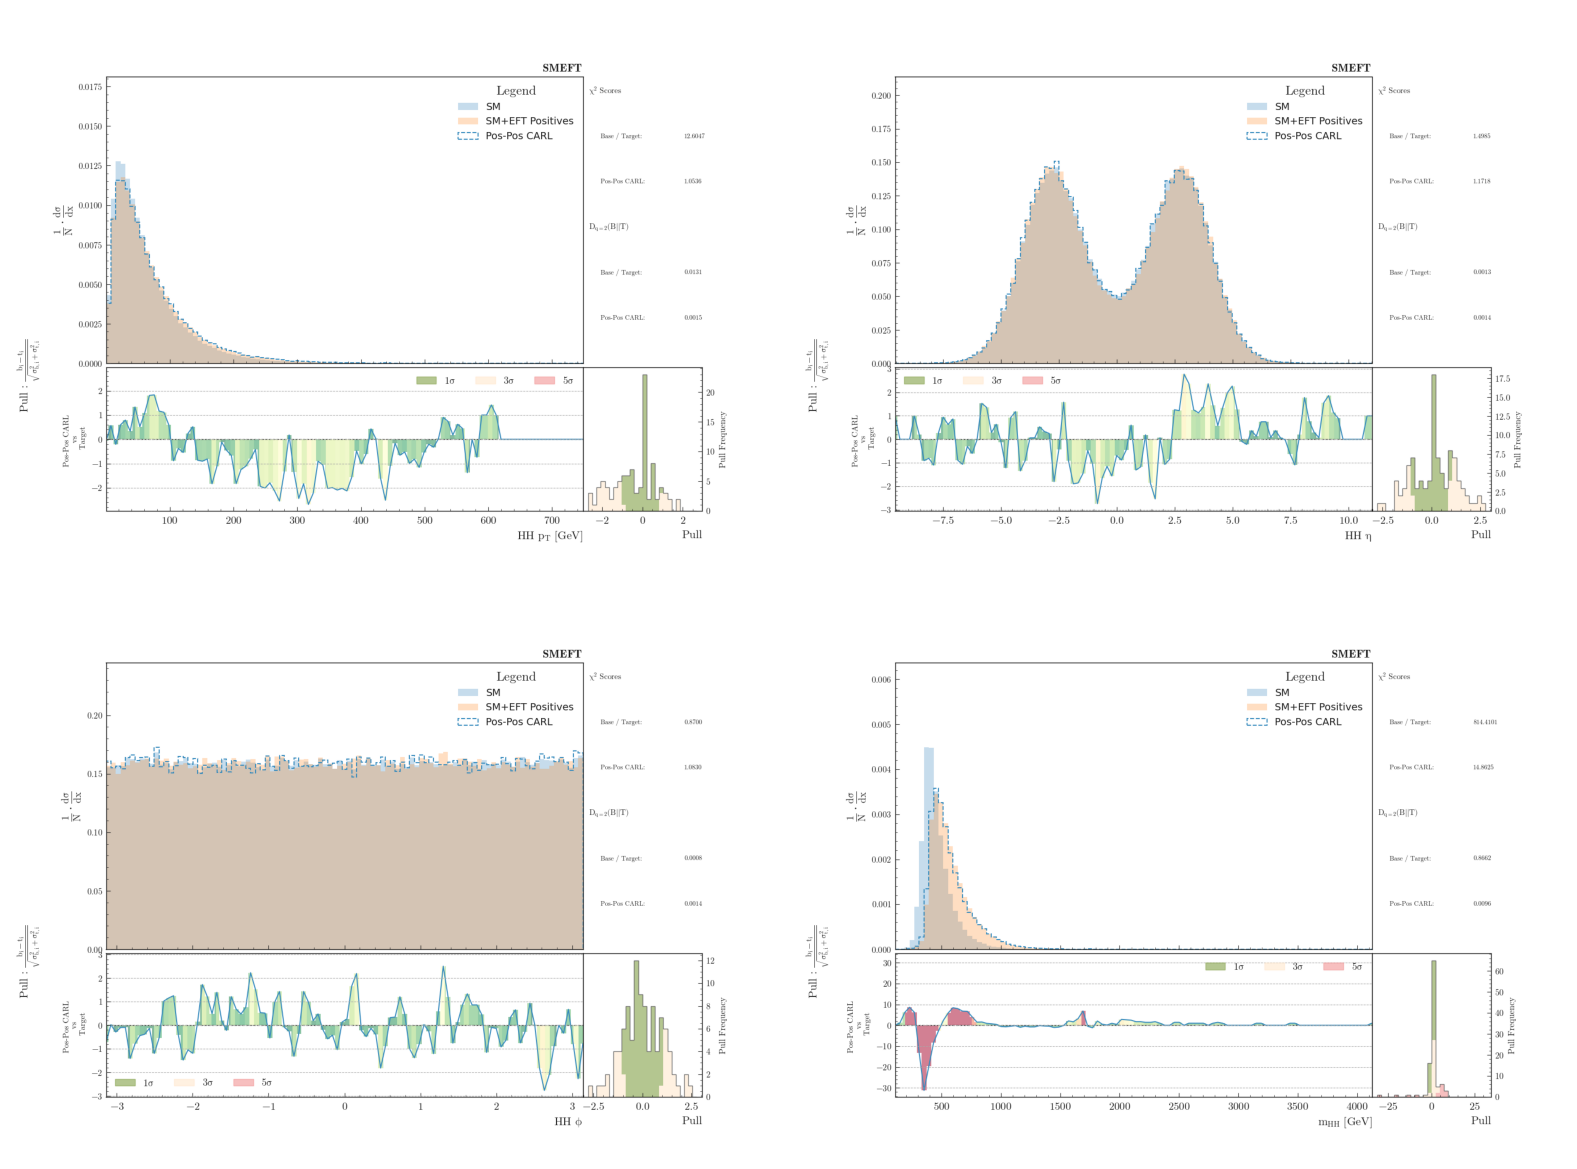

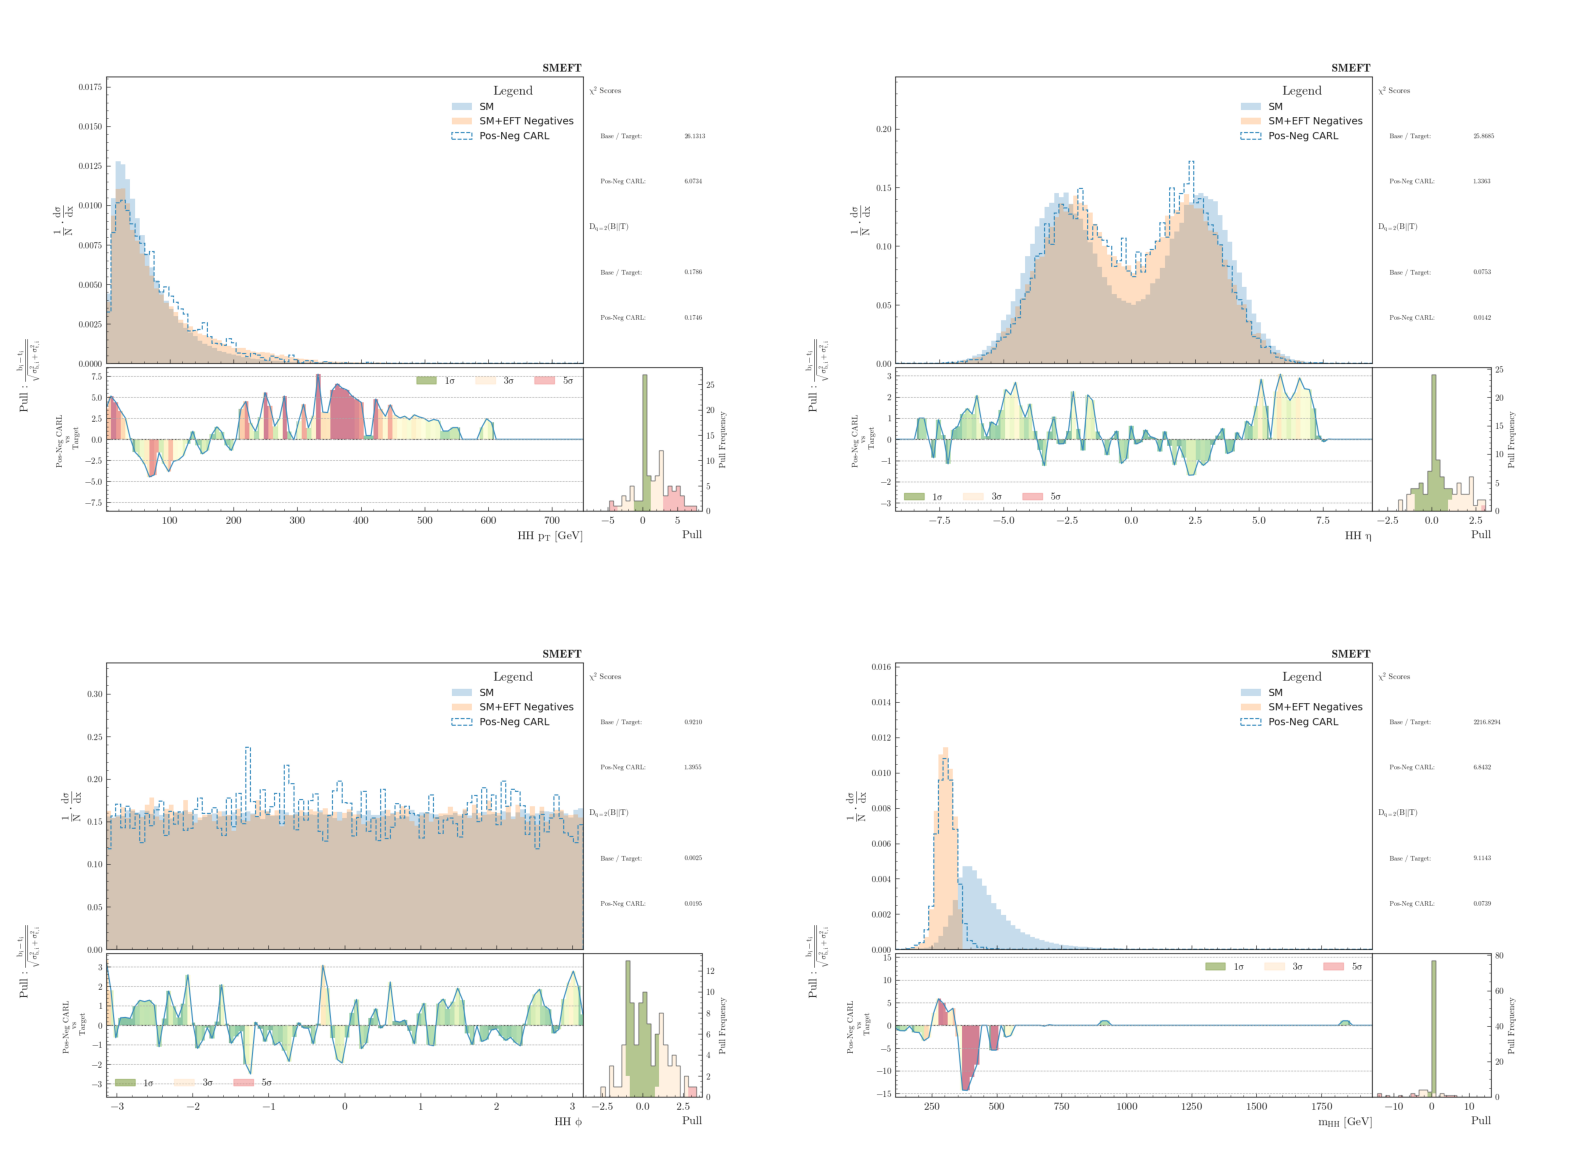

In [23]:
for idx in range(NUM_MODELS):
    plot_closure(r_hats[idx], test_nominal_loaders[idx], test_target_loaders[idx], model_names[idx], target_distribution_names[idx], keys, feature_group='higgs')